<a href="https://colab.research.google.com/github/eisbetterthanpi/RA/blob/main/evergarmin_asfunc_down.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title notes
x-> time, x

teacher/student: time, x, ctx -> sx
pred: sx ->

learnt, learnt
crope, crope?
h

h = self.embed(h) # [b,1/feat,d]
x = torch.cat([h,x], dim=1) # [b, 1/feat + pareto, d]
x = x + self.pos_emb
x[ctx]
trans(x)


h = self.embed(h) # [b,1/feat,d]
h = h + smry_emb
time, x = x[...,0], x[...,1:]
x = x + smpl_emb.repeat
x = torch.cat([h,x], dim=1) # [b, 1/feat + pareto, d]
x[ctx]
pos = zeros cat time
trans(x, pos)


ctx = rand cat simplex/multimask


pred:
x = self.lin(x) # [batch, seq_len, d_model] or [batch, num_context_toks, d_model]
x = x + self.pos_emb[0,context_indices]
pred_tokens = self.cls + self.pos_emb[0,trg_indices]
# print("pred fwd", x.shape, pred_tokens.shape)
x = torch.cat([x, pred_tokens], dim=1) # [batch, seq_len+num_trg_toks, d_model]
out = self.transformer(x)


x = self.lin(x) # [batch, seq_len, d_model] or [batch, num_context_toks, d_model]
x = x + self.head_emb[0,context_indices]
# pred_tokens = self.cls + self.pos_emb[0,trg_indices]
x = torch.cat([x, pred_tokens], dim=1) # [batch, seq_len+num_trg_toks, d_model]
pos = zeros cat time
trans(x, pos)




idx = 1
smry, smpl = act['summary'][idx], act['samples'][idx]

as though same length
make eveerything [seq_len, feat], then [T,f] only select bottom, [t,ff] select sparse?

[2,4]
[5,3]

f is at least 3 -> num known tok >=600
12*200=2400

transform(smpl, 200)
# smpl_ = transform(smpl, 200)

# want num known tok >= ctx+trg
# transform() make ~n known tok, n~4.5*200?
# student:
# [b,T], ctx where t may be repeated

# for pred, t<=200?
# but each feat got diff enc so num known tok ~ feat*200?

want sipmlexmask to base on min visable toks
then ctx+trg=100%, trg ~.4-.6 / ~.7-.8

if min visable toks large (>=85%)

ctx_scale=(.85,1), trg_scale=(.4,.6)
# R�0�ç?����R6y�}
# https://acce55.resetlogin.com/lp/UqUw8cOnP9Xb_IVSNnn7fQ==
# https://cyberready.right-hand.ai/t/ODFkMDExNjktMzhhZC00NmM5LTgwMDQtNGRhZGYxM2I0OGFjXzEzODM0NjRfNjU4MTk=?source=email
# https://scorm.right-hand.ai/index.html?key=Eznu2U1RXli4bnyWARp2lg65818-1383464&path=v1/scormdriver/indexAPI.html&vs=SCORM1.2&instance_id=81d01169-38ad-46c9-8004-4dadf13b48ac&redirect_back_url=https://cyberready.right-hand.ai/trainings?t_id=65819&c_id=44791&atmn_id=null&source=email


test res->test data
validate hyperparams
train long long, many epochs



## top

In [1]:
# @title data
import torch
import torchvision
import torchvision.transforms as transforms
# transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
# transform = transforms.Compose([transforms.ToTensor(),]) # 0.-1.
transform = transforms.Compose([transforms.PILToTensor(),]) # 0-255

# CIFAR10: 60000 32x32 color images in 10 classes, with 6000 images per class
train_data = torchvision.datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.CIFAR10(root='data', train=False, download=True, transform=transform)
batch_size = 64 # 128
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

import numpy as np
import matplotlib.pyplot as plt
def imshow(img):
    # img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# dataiter = iter(train_loader) # get some random training images
# images, labels = next(dataiter)
# print(images.shape) # [batch, 3, 32, 32]
# imshow(torchvision.utils.make_grid(images))

# for img, y in train_data: # 0-255[3, 32, 32], int
for img, y in train_loader: # 0-255[3, 32, 32], int
    print(img.shape)
    # print(img, y)
    break


100%|██████████| 170M/170M [00:06<00:00, 24.4MB/s]


torch.Size([64, 3, 32, 32])


In [2]:
# @title utils
import torch
import torch.nn as nn
import torch.nn.functional as F

def zero_module(module):
    for p in module.parameters():
        p.detach().zero_()
    return module

class op(nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.ops = args
    def __call__(self, x):
        for op in self.ops: x = op(x)
        return x

import inspect
class Seq(nn.Sequential):
    def __init__(self, *args):
        super().__init__(*args)
        for layer in self:
            params = inspect.signature(layer.forward).parameters.keys()
            layer._fwdparams = ','.join(params)

    def forward(self, x, pos=None, masks=None):
        arg_map = {'pos':pos, 'masks':masks}
        for layer in self:
            args = [x]
            # if 'masks' in layer._fwdparams: args.append(masks)
            args.extend(arg_map[p] for p in arg_map if p in layer._fwdparams)
            # print(layer._fwdparams, args)
            x = layer(*args)
        return x

class BatchNorm1d(nn.BatchNorm1d): #
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
    def forward(self, x): return super().forward(x.transpose(-2,-1)).transpose(-2,-1)


In [3]:
# @title RoPE
import torch
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"

class RoPE(nn.Module): # Rotary Positional Embeddings
# class rope(nn.Module): # Rotary Positional Embeddings
    def __init__(self, dim, seq_len=512, base=10000):
        super().__init__()
        self.dim, self.base = dim, base
        theta = 1.0 / (base ** (torch.arange(0, dim, step=2) / dim))
        pos = torch.arange(seq_len).unsqueeze(-1)
        angles = (pos * theta)[None,...,None] # [seq_len, 1] * [dim // 2] -> [1, seq_len, dim // 2, 1]
        self.rot_emb = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1).flatten(-2).to(device) # [seq_len, dim // 2, 2] -> [1, seq_len, dim]

    def forward(self, x):
        seq_len = x.size(1)
        if self.rot_emb.shape[0] < seq_len: self.__init__(self.dim, seq_len, self.base)
        return x * self.rot_emb[:seq_len]


# dim=16
# seq_len=512
# rope = RoPE(dim, seq_len, base=10000)
# x = torch.rand(4,64,dim)
# out = rope(x)
# print(out.shape)


# def RoPE(dim, seq_len=512, base=10000):
#     theta = 1.0 / (base ** (torch.arange(0, dim, step=2) / dim))
#     pos = torch.arange(seq_len).unsqueeze(-1)
#     angles = (pos * theta)[None,...,None] # [seq_len, 1] * [dim // 2] -> [1, seq_len, dim // 2, 1]
#     rot_emb = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1).flatten(-2).to(device) # [1, seq_len, dim // 2, 2] -> [1, seq_len, dim]
#     return rot_emb



class RotEmb(nn.Module): # Rotary Positional Embeddings
    def __init__(self, dim, top=torch.pi, base=10000):
        super().__init__()
        self.theta = top / (base ** (torch.arange(0, dim, step=2, device=device) / dim))
        # self.theta = top / (base ** torch.linspace(0, 1, dim//2, device=device))

    def forward(self, pos): # [batch] in [0,1]
        angles = (pos.unsqueeze(-1) * self.theta).unsqueeze(-1) # [seq_len, 1] * [dim // 2] -> [seq_len, dim // 2, 1]
        rot_emb = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1) # [seq_len, dim // 2, 2]
        return rot_emb.flatten(-2) # [seq_len, dim]

# rotemb = RotEmb(10)
# seq_len=10
# pos = torch.linspace(0,1,seq_len).to(device)#.unsqueeze(-1)
# rot_emb = rotemb(pos)
# print(rot_emb)


def sinusodial(dim, t=512, top=1, base=1000):
    theta = top / (base ** (torch.arange(0, dim, step=2) / dim))
    pos = torch.arange(t).unsqueeze(-1)
    angles = (pos * theta)[None,...,None] # [t,1]*[d//2]->[1,t,d//2,1]
    rot_emb = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1).flatten(-2).to(device) # [1,t,d//2,2]->[1,t,d]
    return rot_emb # [1,t,d]

# from functools import reduce
# def factors(n): # get list of factors of n
#     return set(reduce(list.__add__, ([i, n//i] for i in range(1, int(n**0.5) + 1) if n % i == 0)))
# factor=factors(24*60*60) # factors of 24hrs in sec

class CircularEmb(nn.Module): # Circular Positional Embeddings
    def __init__(self, dim):
        super().__init__()
        factor = [1, 2, 3, 4, 5, 6, 8, 9, 10, 12, 15, 16, 18, 20, 24, 25, 27, 30, 32, 36, 40, 45, 48, 50, 54, 60, 64, 72, 75, 80, 90, 96, 100, 108, 120, 128, 135, 144, 150, 160, 180, 192, 200, 216, 225, 240, 270, 288, 300, 320, 360, 384, 400, 432, 450, 480, 540, 576, 600, 640, 675, 720, 800, 864, 900, 960, 1080, 1152, 1200, 1350, 1440, 1600, 1728, 1800, 1920, 2160, 2400, 2700, 2880, 3200, 3456, 3600, 4320, 4800, 5400, 5760, 7200, 8640, 9600, 10800, 14400, 17280, 21600, 28800, 43200, 86400]
        factor = factor[9:]
        scale = (len(factor)-1)/(dim//2-1)
        mult = torch.tensor([factor[int(i*scale)] for i in range(dim//2)])
        self.theta = 2*torch.pi*86400/24 / mult # longest period is 24hrs, shortest is 3secs

    def forward(self, pos): # [batch,T] in [0,1]
        angles = (pos.unsqueeze(-1) * self.theta).unsqueeze(-1) # [seq_len, 1] * [dim // 2] -> [seq_len, dim // 2, 1]
        rot_emb = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1) # [seq_len, dim // 2, 2]
        # angles = (pos.unsqueeze(-1) * self.theta) # [seq_len, 1] * [dim // 2] -> [seq_len, dim // 2, 1]
        # rot_emb = torch.sin(angles)
        # torch.cos(angles) # [seq_len, dim // 2, 2]
        return rot_emb.flatten(-2)


# ciremb = CircularEmb(dim=8)
# # pos = torch.linspace(0,1,seq_len).to(device).repeat(4,5,1)
# pos = torch.linspace(0,0.3,10).to(device).repeat(4,5,1)/24
# out = ciremb(pos)
# print(out.shape)
# # print(out[0][0])


In [4]:
# @title RoPE correct pos
import torch
import torch.nn as nn
device = 'cuda' if torch.cuda.is_available() else 'cpu'

class RoPE(nn.Module):
    def __init__(self, dim, seq_len=512, top=torch.pi, base=10000):
    # def __init__(self, dim, seq_len=512, min_freq=1, max_freq=400, n_zero=0):
        super().__init__()
        self.dim, self.top, self.base = dim, top, base
        speed = top / (base ** (torch.arange(0, dim, step=2) / dim)) # [dim//2]
        pos = torch.arange(seq_len).unsqueeze(-1) # [t,1]
        # speed = min_freq * (max_freq/min_freq) ** torch.linspace(0,1,dim//2) # [dim//2]
        # pos = torch.linspace(0, 1, seq_len).unsqueeze(-1) # [t,1]
        theta = (speed*pos) # [dim//2]*[t,1]=[t,d//2]
        # if n_zero>0: self.theta[-n_zero:] = 0
        self.theta = theta
        cos, sin = torch.cos(theta), torch.sin(theta)
        # self.affine = torch.stack([cos, -sin, sin, cos], dim=-1).unflatten(-1,(2,2)).to(device) # [t,d//2,4]->[t,d//2,2,2]
        self.affine = torch.stack([cos, -sin, sin, cos], dim=-1).reshape(1,seq_len,dim//2,2,2).to(device) # [t,d//2,4]->[1,t,d//2,2,2]

        # angles = theta[None,...,None] # [seq_len, 1] * [dim//2] -> [1, 1, seq_len, dim//2, 1]
        # self.rot_emb = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1).flatten(-2).to(device) # [1, 1, seq_len, dim//2, 2] -> [1, 1, seq_len, dim]
        # # self.rot_emb = torch.cat([sin, cos], dim=-1).flatten(-2).to(device) # [1, 1, seq_len, dim//2, 2] -> [1,1,seq_len,dim]
        # print('self.rot_emb', self.rot_emb.shape)

    def forward(self, x, ind=None): # [b,h,t,d]/[b,t,d], [b,t]
        seq_len = x.size(-2)
        if ind!=None: seq_len = max(seq_len, ind.max()+1)
        if self.affine.shape[-4] < seq_len: self.__init__(self.dim, seq_len, self.top, self.base)
        affine = self.affine
        if ind!=None:
            b = x.size(0)
            affine = affine.expand(b,*[-1]*4)[torch.arange(b, device=device).unsqueeze(-1), ind]
        if len(x.shape)==4: # [b,h,t,d]
            affine = affine.unsqueeze(1) # [1,h,t,d//2,2,2]
        # print("affine, x",affine.shape, x.unflatten(-1, (-1,2)).unsqueeze(-1).shape) # [64, 4, 2, 2], [64, 8, 10, 8]
        return (affine @ x.unflatten(-1, (-1,2)).unsqueeze(-1)).flatten(-3) # @ [b,h,t,d_head//2,2,1]


# dim=64
# seq_len=60
# # rope = RoPE(dim, seq_len, top=torch.pi, base=100)
# rope = RoPE(dim, 1, top=torch.pi, base=100)
# # rope = RoPE(dim, seq_len, min_freq=1, max_freq=200, n_zero_freqs=0)

# batch=2
# t=50
# x = torch.rand(batch, 4, seq_len, dim, device=device)
# x = torch.rand(batch, seq_len, dim, device=device)
# out = rope(x)
# print("out1", out.shape)
# x = torch.rand(batch, 4, t, dim, device=device)
# x = torch.rand(batch, t, dim, device=device)
# ind = torch.randint(0,seq_len,(batch,t), device=device)
# out = rope(x, ind)
# print("out2", out.shape)

# theta = rope.theta # [t,d//2]
# sim = torch.cos(theta-theta[0].unsqueeze(0)).T
# # print(sim.shape)

# import numpy as np
# import matplotlib.pyplot as plt
# def imshow(img):
#     npimg = img.numpy()
#     print(npimg.shape)
#     plt.rcParams["figure.figsize"] = (8,8)
#     plt.imshow(np.transpose(npimg, (1, 2, 0)))
#     plt.show()

# import torchvision
# imshow(torchvision.utils.make_grid(sim, nrow=dim//2))



In [5]:
# @title CRoPE
import torch
import torch.nn as nn
device = 'cuda' if torch.cuda.is_available() else 'cpu'

class CRoPE(nn.Module): # Circular Rotary Positional Embeddings
    def __init__(self, dim, top=2*torch.pi, min_prd=3, max_prd=86400, n_zero=0):
        super().__init__()
        factor = torch.tensor([1, 2, 3, 4, 5, 6, 8, 9, 10, 12, 15, 16, 18, 20, 24, 25, 27, 30, 32, 36, 40, 45, 48, 50, 54, 60, 64, 72, 75, 80, 90, 96, 100, 108, 120, 128, 135, 144, 150, 160, 180, 192, 200, 216, 225, 240, 270, 288, 300, 320, 360, 384, 400, 432, 450, 480, 540, 576, 600, 640, 675, 720, 800, 864, 900, 960, 1080, 1152, 1200, 1350, 1440, 1600, 1728, 1800, 1920, 2160, 2400, 2700, 2880, 3200, 3456, 3600, 4320, 4800, 5400, 5760, 7200, 8640, 9600, 10800, 14400, 17280, 21600, 28800, 43200, 86400])
        dim =dim//2
        # factor = factor[(factor==min_prd).nonzero().item():] # set fastest rotation period
        # scale = (len(factor)-1)/(dim-1)
        # mult = torch.tensor([factor[int(i*scale)] for i in range(dim)])

        speed = min_prd * (max_prd/min_prd) ** torch.linspace(0,1,dim) # [dim//2]
        idx = (factor - speed.unsqueeze(-1)).abs().argmin(dim=-1) # idx = torch.searchsorted(factor, speed).clamp(max=factor.numel()-1)
        mult = factor[idx]

        self.theta = top / mult # longest period is 24hrs, shortest is 3secs
        if n_zero>0: self.theta[-n_zero:] = 0
        # print("self.theta, mult", self.theta, mult)

    def forward(self, x, pos): # [b,t,d], [b,t] in [0,86400]
        angles = pos.unsqueeze(-1) * self.theta # [b,t,1]*[d]=[b,t,d]
        # print("pos, self.theta", pos, self.theta)
        # rot_emb = torch.sin(angles) # [b,t,d]
        # # rot_emb = torch.stack([torch.sin(angles), torch.cos(angles)], dim=-1).flatten(-2) # [b,t,d//2,2]->[b,t,d]

        # # print("rot_emb", rot_emb)
        # # print("x + rot_emb", x.shape, rot_emb.shape)
        # return x + rot_emb # [seq_len, dim]

        cos, sin = torch.cos(angles), torch.sin(angles)
        affine = torch.stack([cos, -sin, sin, cos], dim=-1).unflatten(-1,(2,2)).to(device) # [b,t,d//2,4]->[b,t,d//2,2,2]
        # print("affine, x", affine.shape, x.shape) # [2, 50, 64, 2, 2], [2, 50, 64]
        if len(x.shape)==4: # [b,h,t,d]
            h=x.shape[1]
            affine = affine.unsqueeze(1).repeat(1,h,1,1,1,1)
        return (affine @ x.unflatten(-1, (-1,2)).unsqueeze(-1)).flatten(-3) # [b,t,d//2,2,2] @ [b,t,d//2,2,1] -> [b,t,d]


dim=16
# rope = CRoPE(dim, n_zero=dim//8)
rope = CRoPE(dim, top=2*torch.pi, n_zero=0) # top= 1 torch.pi 2*torch.pi

batch=2
t=200
x = torch.rand(batch, t, dim, device=device)
# x = torch.rand(batch, 4, t, dim, device=device)
# x = torch.stack([torch.ones(dim//2), torch.zeros(dim//2)], dim=-1).flatten()[None,None,:].expand(batch,t,-1)
# x = torch.tensor([1.,0.])[None,None,:].repeat(batch,t,dim//2)

# pos = torch.rand((batch,t), device=device)
pos = torch.linspace(-1,1,t).unsqueeze(0).expand(batch,-1)*6000 # 86400

theta = rope(x, pos)[0] # [t,d]



# # print(theta)
# # print(torch.norm(theta, dim=-1))
print(theta.shape, theta[0].T.shape)
# sim = (theta@theta[0].T) #/ (torch.norm(theta, dim=-1)*torch.norm(theta[0], dim=0))
# print(sim.shape)
# # print(sim)


# import numpy as np
# import matplotlib.pyplot as plt
# def imshow(img): # [c,h,w]
#     npimg = img.numpy()
#     plt.rcParams["figure.figsize"] = (8,8)
#     plt.imshow(np.transpose(npimg, (1, 2, 0)))
#     plt.show()

# # import torchvision
# imshow(theta.T.unsqueeze(0))
# # imshow(torchvision.utils.make_grid(sim, nrow=dim//2))

# plt.rcParams["figure.figsize"] = (4,4)
# plt.plot(sim)
# plt.show()



torch.Size([200, 16]) torch.Size([16])


/tmp/ipykernel_156/3435126374.py:62: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  print(theta.shape, theta[0].T.shape)


In [6]:
# @title AttentionBlock pos
import torch
import torch.nn as nn
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# from .rope import RoPE
# from .rope_correct import RoPE
# from .crope import CRoPE
# from .utils import zero_module

class SelfAttn(nn.Module):
    def __init__(self, dim, n_heads):
        super().__init__()
        self.dim, self.n_heads = dim, n_heads
        d_head = dim//n_heads
        self.rope = RoPE(d_head, seq_len=256, top=torch.pi, base=10000)
        self.crope = CRoPE(d_head, top=2*torch.pi, min_prd=3, n_zero=0)
        self.qkv = nn.Linear(dim, dim*3, bias=False)
        self.lin = zero_module(nn.Linear(dim, dim))
        self.scale = d_head**-.5

    # def forward(self, x): # [b,t,d]
    def forward(self, x, pos=None): # [b,t,d]
        # print('SelfAttn', x.shape, pos)
        q,k,v = self.qkv(x).unflatten(-1, (self.n_heads,-1)).transpose(1,2).chunk(3, dim=-1) # [b, t, n_heads, d_head] -> [b, n_heads, t, d_head]
        if pos!=None: q, k = self.crope(q, pos), self.crope(k, pos)
        # else: q, k = self.rope(q), self.rope(k)

        # x = F.scaled_dot_product_attention(q,k,v, attn_mask=None) # https://pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html
        q, k = q.softmax(dim=-1)*self.scale, k.softmax(dim=-2)
        context = k.transpose(-2,-1) @ v # [batch, n_heads, d_head, d_head]
        x = q @ context # [b,n_heads,t,d_head]
        x = x.transpose(1,2).flatten(2)
        return self.lin(x)

class AttentionBlock(nn.Module):
    def __init__(self, d_model, n_heads, mult=4, drop=0.):
        super().__init__()
        self.d_model = d_model
        # self.norm = nn.RMSNorm(d_model, elementwise_affine=False) # LayerNorm RMSNorm
        self.norm1, self.norm2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.drop = nn.Dropout(drop)
        self.attn = SelfAttn(d_model, n_heads)
        act = nn.GELU() # ReLU GELU
        ff_dim=d_model*mult
        self.ff = nn.Sequential(
            # nn.RMSNorm(d_model), act, nn.Dropout(drop), nn.Linear(d_model, ff_dim),
            # nn.RMSNorm(ff_dim), act, nn.Dropout(drop), zero_module(nn.Linear(ff_dim, d_model))
            nn.RMSNorm(d_model), nn.Dropout(drop), nn.Linear(d_model, ff_dim), act,
            nn.RMSNorm(ff_dim), nn.Dropout(drop), zero_module(nn.Linear(ff_dim, d_model))
        )

    # def forward(self, x): # [b,t,d]
    def forward(self, x, pos=None): # [b,t,d]
        # print('attnblk fwd',x.shape)
        # x = x + self.drop(self.attn(self.norm1(x)))
        x = x + self.drop(self.attn(self.norm1(x), pos))
        x = x + self.ff(x)
        # x = x + self.drop(self.ff(self.norm2(x)))
        return x



In [7]:
# @title random_masking
import torch

def rand_mask(bt, trg_scale=(.4,.7), msk=None): # [b,feat], F->mask
    b, t = bt
    noise = torch.rand(b,t, device=device)
    # print('rand_mask', noise.shape, msk.shape)
    if msk!=None: noise*=msk#.flatten(1) # +inf to non msk/nan area
    n_vis = msk.sum(dim=-1).min() if msk!=None else t # min num visable toks across batch
    trg_len = int(n_vis * (torch.rand(1, device=device) * (trg_scale[1] - trg_scale[0]) + trg_scale[0])) # in (min_s, max_s) # all blocks same size
    _, ind = torch.topk(noise, k=n_vis, dim=-1, sorted=False) # val, ind -> [b,len_mask]
    # print(n_vis, trg_len)
    # ind = torch.randperm(len(ind), generator=ind)
    ind = ind.index_select(-1, torch.randperm(ind.size(-1), device=device)) # shuffle last dim

    ctx_ind, trg_ind = ind[:,trg_len:], ind[:,:trg_len]
    # print(ind.shape, ctx_ind.shape, trg_ind.shape)
    return ctx_ind, trg_ind

b,t = 2,7
x = torch.randn(b,t, device=device)
msk = torch.rand(b,t, device=device)<.7
print(msk)
ctx_ind, trg_ind = rand_mask(x.shape, trg_scale=(.0,.0), msk=msk)
print(ctx_ind, trg_ind)



tensor([[False,  True,  True,  True,  True,  True, False],
        [False,  True,  True,  True,  True,  True, False]])
tensor([[4, 3, 2, 1, 5],
        [2, 5, 4, 3, 1]]) tensor([], size=(2, 0), dtype=torch.int64)


torch.Size([16, 64]) torch.Size([16, 29])


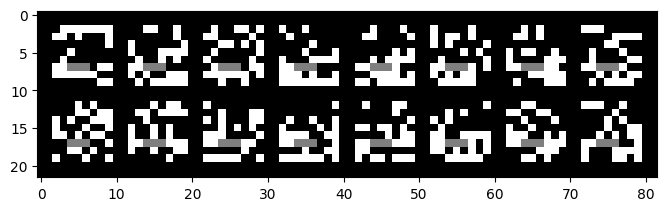

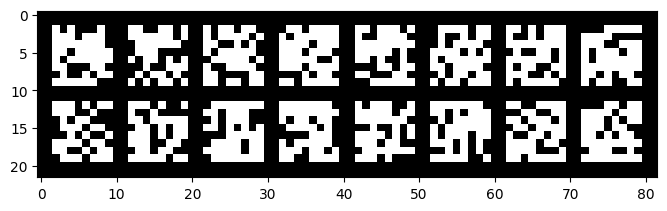

In [8]:
# @title Random Fourier Features noise
import math
import torch

# Random Fourier Features: ∑_k] a_k * cos(ω_k ⋅ x + 𝜙_k)
def rff_noise(x, out_dim, n_freqs=128, scale=1): # [...,n_Dim]
    space, in_dim, device = x.shape[:-1], x.shape[-1], x.device
    x = x.flatten(0,-2) # [N,in]
    w = torch.randn(out_dim, n_freqs, in_dim, device=device) * scale
    phi = torch.empty(out_dim, n_freqs, device=device).uniform_(0,2*math.pi)
    a = torch.randn(out_dim, n_freqs, device=device) / math.sqrt(n_freqs)
    y = torch.cos(torch.einsum("ofd,...d->...of", w, x) + phi) # [N,out,freq]
    return torch.einsum("of,...of->...o", a, y).unflatten(0,space) # [...,out]

# def rffmask2d(bhw, ctx_scale=(.85,1.), trg_scale=(.6,.8), chaos=[1,.5]): # ctx_scale > trg_scale
def rffmask2d(bhw, ctx_scale=(.05,.5), trg_scale=(.6,.8), chaos=[4,1]): # ctx_scale > trg_scale
    b,h,w = bhw
    ctx_mask_scale = torch.rand(1) * (ctx_scale[1] - ctx_scale[0]) + ctx_scale[0] # in (min_s, max_s) # all blocks same size
    trg_mask_scale = torch.rand(1) * (trg_scale[1] - trg_scale[0]) + trg_scale[0]
    seq = h*w
    ctx_len, trg_len = int(seq*ctx_mask_scale), int(seq*trg_mask_scale)
    # print(ctx_len, trg_len)
    # ctx_len = ctx_len - trg_len
    ctx_len = min(ctx_len, seq-trg_len)

    ix, iy = torch.linspace(0, chaos[0], h), torch.linspace(0, chaos[0], w)
    x = torch.stack(torch.meshgrid(ix, iy, indexing="ij"), dim=-1) # [t,h,w,b] / [h,w,b]
    noise = rff_noise(x, b).flatten(0,-2).T # [h,w,b]->[h*w,b]->[b,h*w]
    _, trg_ind = torch.topk(noise, trg_len, dim=1, sorted=False)

    ix, iy = torch.linspace(0, chaos[1], h), torch.linspace(0, chaos[1], w)
    x = torch.stack(torch.meshgrid(ix, iy, indexing="ij"), dim=-1) # [t,h,w,b] / [h,w,b]
    noise = rff_noise(x, b).flatten(0,-2).T
    noise.scatter_(1, trg_ind, -torch.inf).flatten()
    _, ctx_ind = torch.topk(noise, ctx_len, dim=1, sorted=False)
    return ctx_ind, trg_ind

def rffmask2d(bhw, ctx_scale=(.05,.5), trg_scale=(.6,.8), chaos=[4,1], msk=None): # ctx_scale > trg_scale, T->msk
    b,h,w = bhw
    ctx_mask_scale = torch.rand(1) * (ctx_scale[1] - ctx_scale[0]) + ctx_scale[0] # in (min_s, max_s) # all blocks same size
    trg_mask_scale = torch.rand(1) * (trg_scale[1] - trg_scale[0]) + trg_scale[0]
    seq = h*w if msk==None else msk.sum(dim=-1).min() # min num visable toks across batch

    ctx_len, trg_len = int(seq*ctx_mask_scale), int(seq*trg_mask_scale)
    # print(ctx_len, trg_len)
    # ctx_len = ctx_len - trg_len
    ctx_len = min(ctx_len, seq-trg_len)

    ix, iy = torch.linspace(0, chaos[0], h), torch.linspace(0, chaos[0], w)
    x = torch.stack(torch.meshgrid(ix, iy, indexing="ij"), dim=-1) # [t,h,w,b] / [h,w,b]
    noise = rff_noise(x, b).flatten(0,-2).T # [h,w,b]->[h*w,b]->[b,h*w]
    if msk!=None: noise[msk] = -torch.inf
    _, trg_ind = torch.topk(noise, trg_len, dim=1, sorted=False)

    ix, iy = torch.linspace(0, chaos[1], h), torch.linspace(0, chaos[1], w)
    x = torch.stack(torch.meshgrid(ix, iy, indexing="ij"), dim=-1) # [t,h,w,b] / [h,w,b]
    noise = rff_noise(x, b).flatten(0,-2).T
    if msk!=None: noise[msk] = -torch.inf
    print(noise.shape, trg_ind.shape)
    noise.scatter_(1, trg_ind, -torch.inf).flatten()
    _, ctx_ind = torch.topk(noise, ctx_len, dim=1, sorted=False)
    return ctx_ind, trg_ind


b=16
hw=(8,8)
# hw=(32,32)

msk = None
msk = torch.rand(b,hw[0]*hw[1], device=device)<.7 # T->msk

# cxt_inds, trg_inds = rffmask2d((b,)+hw, ctx_scale=(.85,1.), trg_scale=(.2,.8), chaos=[3,1])
# cxt_inds, trg_inds = rffmask2d((b,)+hw, ctx_scale=(.85,1.), trg_scale=(.2,.8), chaos=[1,.5])
cxt_inds, trg_inds = rffmask2d((b,)+hw, ctx_scale=(.05,.5), trg_scale=(.2,.8), chaos=[4,1], msk=msk)
# print(cxt_inds, trg_inds)

import numpy as np
import matplotlib.pyplot as plt
def imshow(img):
    npimg = img.numpy()
    plt.rcParams["figure.figsize"] = (8,8)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()
# imshow(mask)

mask = torch.zeros(b ,math.prod(hw), device=device)
mask[torch.arange(b).unsqueeze(-1), trg_inds] = 1
mask[torch.arange(b).unsqueeze(-1), cxt_inds] = .5
# print((mask==1).sum(1))
# print((mask==.5).sum(1))
mask = mask.reshape(b,1,*hw)
import torchvision
imshow(torchvision.utils.make_grid(mask, nrow=8))

msk = msk.reshape(b,1,*hw).float()
import torchvision
imshow(torchvision.utils.make_grid(msk, nrow=8))



In [9]:
# @title TransformerModel/Predictor all
import torch
import torch.nn as nn
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# class FeatureWiseLinear(nn.Module):
#     def __init__(self, feat, d):
#         super().__init__()
#         self.feat, self.d = feat, d
#         self.conv = nn.Conv1d(feat, feat*d, kernel_size=1, groups=feat)

#     def forward(self, x): # [b,feat]->[b,feat,d]
#         head = x.shape[:-1]
#         if x.ndim>=3: x = x.flatten(0,-2)
#         return self.conv(x.unsqueeze(-1)).reshape(*head, self.feat, self.d) # [b,feat,1]->[b,feat*d,1]->[b,feat,d]

# class LinEmb(nn.Module):
#     def __init__(self, d_model):
#         super().__init__()
#         self.lin = nn.Linear(1, d_model)

#     def forward(self, x): # [b,feat] / [b,t,in]
#         return self.lin(x.float().unsqueeze(-1)) # [b,feat,d] / [b,t,in,d]

class nLinear(nn.Module):
    def __init__(self, n, in_dim, out_dim=None):
        super().__init__()
        self.n, self.in_dim, self.out_dim = n, in_dim, out_dim or in_dim
        self.conv = nn.Conv1d(n*in_dim, n*self.out_dim, kernel_size=1, groups=n, bias=False)
        # self.learnt = nn.Parameter(torch.randn(n, dim)*.02)
        self.norm = nn.RMSNorm(self.out_dim) # LayerNorm RMSNorm
        self.act = nn.SELU() # ReLU SELU

    def forward(self, x): # [b,feat,d] / [b,t,in,d]
        bt = x.shape[:-2]
        out = self.conv(x.reshape(-1, self.n * self.in_dim, 1)).reshape(*bt, self.n, self.out_dim)
        # out = x * self.learnt
        out = self.act(self.norm(out))
        return out

class TransformerModel(nn.Module):
    def __init__(self, summary_dict, samples_dict, d_model, out_dim=None, n_heads=4, nlayers=1, drop=0, msk_tok=torch.nan):
        super().__init__()
        feat, xin = len(summary_dict), len(samples_dict) -1
        # samples_dict.pop('time', 'Key not found') # time as pos
        # self.hin = FeatureWiseLinear(len(summary_dict), d_model)
        # self.lin = FeatureWiseLinear(len(samples_dict), d_model)
        self.hin = nLinear(feat, d_model)
        self.lin = nLinear(xin, d_model, d_model//1)

        self.patch = 8
        # self.conv = nn.Conv1d(d_model, d_model, kernel_size=7, stride=4, padding=7//2)
        self.conv = nn.Sequential(
            # nn.Conv1d(d_model, d_model, 1, 1, 0, bias=False)
            # nn.Conv1d(d_model, d_model, 8, 8, 0, bias=False)

            # nn.Conv1d(d_model, d_model,3,2,3//2), nn.BatchNorm1d(d_model), nn.ReLU(),# nn.MaxPool1d(2,2),
            # nn.Conv1d(d_model, d_model,3,1,3//2),

            # nn.Conv1d(d_model//4, d_model//2,7,2,7//2), nn.BatchNorm1d(d_model//2), nn.SELU(),# nn.MaxPool1d(2,2), # ReLU SELU
            # nn.Conv1d(d_model//2, d_model,5,1,5//2),


            # nn.Conv1d(d_model, d_model, kernel_size=7, stride=4, padding=7//2), nn.BatchNorm1d(d_model), nn.ReLU(),
            # nn.Conv1d(d_model, d_model, kernel_size=5, stride=2, padding=5//2)

            # nn.Conv1d(d_model, d_model, 7, 2, 7//2, bias=False), nn.BatchNorm1d(d_model), nn.ReLU(),
            # nn.Conv1d(d_model, d_model, 5, 2, 5//2, bias=False), nn.BatchNorm1d(d_model), nn.ReLU(),
            nn.Conv1d(d_model, d_model, 3, 2, 3//2, bias=False), nn.BatchNorm1d(d_model), nn.SELU(),
            nn.Conv1d(d_model, d_model, 3, 2, 3//2, bias=False), nn.BatchNorm1d(d_model), nn.SELU(),
            nn.Conv1d(d_model, d_model, 3, 2, 3//2, bias=False)

            # nn.Conv1d(d_model, d_model, 7, 1, 7//2), nn.BatchNorm1d(d_model), nn.MaxPool1d(2), nn.ReLU(),
            # nn.Conv1d(d_model, d_model, 5, 1, 5//2), nn.BatchNorm1d(d_model), nn.MaxPool1d(2), nn.ReLU(),
            # nn.Conv1d(d_model, d_model, 3, 1, 3//2), nn.BatchNorm1d(d_model), nn.MaxPool1d(2),
            )

        # self.pos_emb = nn.Parameter(torch.randn(1, 1+200//8, d_model)*.02)
        self.hpos = nn.Parameter(torch.randn(1,feat,d_model)*.02)
        # self.xpos = sinusodial(d_model, 200//self.patch, base=1000).unsqueeze(-2) # 1td->1t1d
        self.xpos = sinusodial(d_model, 12, base=1000).unsqueeze(-2) # 1td->1t1d

        self.transformer = Seq(*[AttentionBlock(d_model, n_heads=n_heads) for _ in range(nlayers)])
        self.norm = nn.RMSNorm(d_model) # LayerNorm RMSNorm
        self.out = nn.Linear(d_model, out_dim) if out_dim and out_dim != d_model else None

        # self.msk_tok, self.pad_tok = msk_tok, pad_tok
        self.smry_unk = nn.Parameter(torch.randn(1, feat, d_model)*.02) # [1,feat,d]
        self.smpl_unk = nn.Parameter(torch.randn(1, 1, xin, d_model)*.02)
        # self.smry_unk = torch.full((1, feat, d_model), -7) # [1,feat,d]
        # self.smpl_unk = torch.full((1, 1, xin, d_model), -7)

        emb_dict = {'lin': RotEmb(d_model, top=1, base=100), 'cyc':CircularEmb(d_model), 'cat':op(lambda x: x.round().int(), nn.Embedding(133, d_model)) ,'log': RotEmb(d_model, top=torch.pi, base=10), 'symlog': RotEmb(d_model, top=torch.pi, base=10)} # 133: Activity Profile Options on Garmin Watches https://support.garmin.com/en-SG/?faq=g9VOolzNBr08b7mfclmxt7 ctrl-f GTCollapseContent
        # emb_dict = {'lin': LinEmb(d_model), 'cyc':CircularEmb(d_model), 'cat':op(lambda x: x.round().int(), nn.Embedding(133, d_model)) ,'log': LinEmb(d_model), 'symlog': LinEmb(d_model)} # 133: Activity Profile Options on Garmin Watches https://support.garmin.com/en-SG/?faq=g9VOolzNBr08b7mfclmxt7 ctrl-f GTCollapseContent
        self.smry_emb = nn.ModuleList([emb_dict[v] for v in summary_dict.values()])
        self.smpl_emb = nn.ModuleList([emb_dict[v] for v in samples_dict.values()])

    def embed(self, x, emb_lst=None, lin=None, unk_vec=None): # [b,feat]/[b,t,in], ModuleList, [1,feat,d]
        # # msk = x==self.msk_tok # [b,t,in]
        msk = x.isnan() # [b,feat] / [b,t,in]
        x = torch.nan_to_num(x, nan=0.)
        if emb_lst!=None: x = torch.cat([emb(xx) for emb, xx in zip(emb_lst, x.split(1, dim=-1))], dim=-2) # [b,feat]->[b,feat,d] / [b,t,feat]->[b,t,feat,d]
        if unk_vec!=None:
            # print('embed', x.shape, msk.shape, unk_vec.shape, unk_vec.expand_as(x).shape) # [b,feat,d], [b,feat], [feat,d], [b,feat,d]
            # x[msk] = unk_vec.expand_as(x)[msk].to(x.dtype) # [b,feat,d] / [b,t,feat,d]
            x = torch.where(msk.unsqueeze(-1), unk_vec, x)
        # if lin!=None: x = lin(x) # [b,feat]->[b,feat,d] / [b,t,in]->[b,t,in,d]
        if lin!=None: x = lin(x) # [b,feat,d] / [b,t,in,d]
        return x, msk # [b,feat,d] / [b,t,in,d]

    def forward(self, h, x, ctx_ind=None): # [b,feat], [b,t,in], [b,feat+t*in,d]
        pos, x = x[...,0], x[...,1:] # [b,t], [b,t,smpl]
        # print('transfwd nan h x bef', h.isnan().any(), x.isnan().any(), self.smry_unk.isnan().any(), self.smpl_unk.isnan().any())
        # print("Trans fwd h x",h.shape, x.shape)
        h, hmsk = self.embed(h, emb_lst=self.smry_emb, lin=self.hin, unk_vec=self.smry_unk) # [b,feat,d]
        x, xmsk = self.embed(x, emb_lst=self.smpl_emb, lin=self.lin, unk_vec=self.smpl_unk) # [b,t,in,d]

        b,t,xin,d = x.shape
        x = self.conv(x.permute(0,2,3,1).flatten(0,1)).unflatten(0, (b,-1)).permute(0,3,1,2) # [b,t,in,d]->[b*in,d,t]->[b,t,in,d]
        xmsk = F.interpolate(xmsk.transpose(-2,-1).float(), (x.shape[1]), mode='nearest').bool().transpose(-2,-1) # [b,t,xin]->[b,t//8,xin]

        h = h + self.hpos # [b,feat,d]+[1,f,d]
        x = x + self.xpos # [b,t,in,d]+[1,t,1,d]
        x = torch.cat([h,x.flatten(1,2)], dim=1) # [b,feat+t*in,d]

        msk = ~torch.cat([hmsk, xmsk.flatten(1)], dim=-1) # [b,feat+(t/8)*in] ; T->keep
        ctx_inds, trg_ind = rand_mask(x.shape[:-1], trg_scale=(.0,.0), msk=msk)
        if ctx_ind != None: x = x[torch.arange(x.shape[0]).unsqueeze(-1), ctx_ind] # [b,ctx,d]
        # if h.isnan().any() or x.isnan().any(): print('transfwd nan h x', h.isnan().any(), x.isnan().any())

        pos = torch.cat([torch.zeros(*h.shape[:2]), pos], dim=-1) # [b,feat+t]
        # try: print("Trans fwd",x.shape, ctx_ind.shape)
        # except: print("Trans fwd noind",x.shape, self.pos_emb.shape, self.pos_emb[:,:x.shape[1]].shape)
        if ctx_ind != None:
            x = x[torch.arange(x.shape[0]).unsqueeze(-1), ctx_ind] # [b,ctx,d]
            pos = pos[torch.arange(x.shape[0]).unsqueeze(-1), ctx_ind] # [b,ctx,d]
        # print("TransformerModel x pos",x.shape, pos.shape)
        x = self.transformer(x, pos)

        # x = self.transformer(x)
        out = self.norm(x)
        if self.out: out = self.out(out)
        return out # [b,22+t,d]

# time as pos
# convlin instead of rotemb



In [16]:

b,f,t,xin = 2, 5,7,3
hmsk, xmsk = torch.rand(b,f)>.5, torch.rand(b,t,xin)>.5
X = torch.cat([hmsk.sum(-1).unsqueeze(-1), xmsk.sum(-1)], dim=-1)

print(X.shape)
# idx = torch.arange(t+1, device=device).expand(b,-1)  # [B, T]
idx = torch.arange(t+1, device=device).repeat(b)  # [B, T]
Y = torch.repeat_interleave(idx, X.flatten())
Y = Y.reshape(b,-1)
print(X)
print(Y)


torch.Size([2, 8])
tensor([[1, 1, 2, 2, 0, 1, 2, 0],
        [3, 1, 1, 2, 2, 1, 1, 2]])
tensor([[0, 1, 2, 2, 3, 3, 5, 6, 6, 0, 0],
        [0, 1, 2, 3, 3, 4, 4, 5, 6, 7, 7]])


In [10]:
# @title wJEPA
import torch
import torch.nn as nn
import torch.nn.functional as F
device = "cuda" if torch.cuda.is_available() else "cpu"

class SeqJEPA(nn.Module):
    # def __init__(self, in_dim=32, d_model=64, out_dim=None, nlayers=2, n_heads=4):
    # def __init__(self, summary_dict, in_dim=32, d_model=64, out_dim=None, nlayers=2, n_heads=4):
    def __init__(self, summary_dict, samples_dict, d_model=64, out_dim=None, nlayers=2, n_heads=4, msk_tok=torch.nan):
        super().__init__()
        if out_dim is None: out_dim = d_model
        self.d_model, self.out_dim = d_model, out_dim
        # self.d_model = d_model
        # self.patch_size = 1 # 4
        self.student = TransformerModel(summary_dict, samples_dict, d_model, out_dim=out_dim, n_heads=n_heads, nlayers=nlayers, drop=0., msk_tok=msk_tok)

    def forward(self, h, x): # [b,23], [b,seq_len,11]
        sx = self.student(h, x).mean(dim=1)
        # sx = F.layer_norm(sx, (sx.size(-1),))
        return sx


## SeqJEPA

In [ ]:
# @title SeqJEPA

# summary_dict = {'duration': 'log', 'startTime':'cyc', 'activity': 'cat', 'ave_hr': 'lin', 'calories': 'log', 'max_hr': 'lin', 'steps': 'log', 'RunCadence': 'lin', 'speed': 'log', 'pace': 'log', 'dist': 'log', 'maxPace': 'log', 'maxRunCadence': 'lin', 'maxSpeed': 'log', 'lat': 'lin', 'long': 'lin', 'ElevationGain': 'log', 'ElevationLoss': 'log', 'ave_SwimCadence': 'lin', 'ActiveLengths': 'log', 'ave_BikeCadence': 'lin', 'maxBikeCadence': 'lin'}
# samples_dict = {'time': 'cyc', 'hr': 'lin', 'dist': 'log', 'temp': 'lin', 'speed': 'log', 'lat': 'lin', 'long': 'lin', 'elevation': 'symlog', 'stepsPerMinute': 'lin', 'power': 'log', 'bikeCadence': 'lin'}

summary_dict = {str(i):'lin' for i in range(32)}
# {'time': 'cyc',}
samples_dict = {str(i):'lin' for i in range(32)}
print(samples_dict)

device = "cuda" if torch.cuda.is_available() else "cpu"
d_model = 64
# in_dim = smpl.shape[-1]
# seqjepa = SeqJEPA(summary_dict, samples_dict, d_model, out_dim=d_model, nlayers=1, n_heads=8, msk_tok=msk_tok).to(device)
seqjepa = SeqJEPA(summary_dict, samples_dict, d_model, out_dim=d_model, nlayers=1, n_heads=8).to(device)

print(sum(p.numel() for p in seqjepa.parameters() if p.requires_grad)) # 27584
print(sum(p.numel() for p in seqjepa.student.transformer.parameters() if p.requires_grad)) # 27584
# print(sum(p.numel() for p in seqjepa.student.conv.parameters() if p.requires_grad)) # 27584

img_ = img.transpose(1,2).flatten(-2).to(device) # [b, 3, 32, 32] # [b,c,h,w]->[b,h,c*w]
h, x = img_[...,0], img_[...,1:].transpose(1,2)

out = seqjepa(h, x)
# print(out.shape)
# # print(out)

# 32*3-1=95; 95/8~11

import torch.nn as nn
class Classifier(nn.Module):
    def __init__(self, in_dim, out_dim, drop=.0):
        super().__init__()
        self.drop = nn.Dropout(drop)
        self.lin = nn.Linear(in_dim, out_dim)#, bias=False)

    def forward(self, sx): # [b,d]
        return self.lin(self.drop(sx))

# classifier = Classifier(seqjepa.out_dim, len(cdf.columns)).to(device)
classifier = Classifier(seqjepa.out_dim, 10).to(device)
# coptim = torch.optim.SGD(classifier.parameters(), lr=1e-3)
# coptim = torch.optim.SGD(classifier.parameters(), lr=1e0)
supervisedoptim = torch.optim.AdamW([{'params': seqjepa.parameters()}, {'params': classifier.parameters(), 'lr': 1e-3}], lr=1e-3, weight_decay=1e-2)
# supervisedoptim = torch.optim.AdamW([{'params': seqjepa.parameters()}, {'params': classifier.parameters(), 'lr': 1e-2}], lr=1e-2)
# def warmup_scheduler(optimizer, warmup_steps=40):
#     def lr_lambda(step):
#         if step < warmup_steps: return (step + 1) / warmup_steps
#         return 1
#     return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
# scheduler = warmup_scheduler(supervisedoptim, 100)

out = classifier(out)
print(out.shape)
# print(out)

# linemb
# loss: 1.610658  [39936/50000]
# loss: 1.272667  [44928/50000]
# loss: 1.348527  [49920/50000]
#  Accuracy: 52.6%, Avg loss: 1.331176 # time:  456.3933832645416



{'0': 'lin', '1': 'lin', '2': 'lin', '3': 'lin', '4': 'lin', '5': 'lin', '6': 'lin', '7': 'lin', '8': 'lin', '9': 'lin', '10': 'lin', '11': 'lin', '12': 'lin', '13': 'lin', '14': 'lin', '15': 'lin', '16': 'lin', '17': 'lin', '18': 'lin', '19': 'lin', '20': 'lin', '21': 'lin', '22': 'lin', '23': 'lin', '24': 'lin', '25': 'lin', '26': 'lin', '27': 'lin', '28': 'lin', '29': 'lin', '30': 'lin', '31': 'lin'}
355840
50112
torch.Size([64, 10])


In [ ]:
# @title train test function
import torch
import torch.nn.functional as F

def train(model, classifier, dataloader, optim, scheduler=None):
    size = len(dataloader.dataset)
    model.train()
    for i, (img, c) in enumerate(dataloader):
        img = img.transpose(1,2).flatten(-2).to(device) # [b, 3, 32, 32] # [b,c,h,w]->[b,h,c*w]
        h, x = img[...,0], img[...,1:].transpose(1,2)
        c = c.to(device)
        # h, x = h.float().to(device), x.float().to(device)
        sx = model(h, x)
        c_ = classifier(sx)
        loss = F.cross_entropy(c_, c)
        optim.zero_grad()
        loss.backward()
        optim.step()
        if i % (size//(10* len(x))) == 0:
            loss, current = loss.item(), i * len(x)
            # loss_list.append(loss)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
        try: wandb.log({"loss": loss.item()})
        except: pass

def test(model, classifier, dataloader):
    model.eval()
    test_loss, correct = 0, 0
    for i, (img, c) in enumerate(dataloader):
        img = img.transpose(1,2).flatten(-2).to(device) # [b, 3, 32, 32] # [b,c,h,w]->[b,h,c*w]
        h, x = img[...,0], img[...,1:].transpose(1,2)
        c = c.to(device)
        with torch.no_grad():
            sx = model(h, x)
            c_ = classifier(sx)
        test_loss += F.cross_entropy(c_, c).item()
        correct += (c_.argmax(1) == c).sum().item()
    test_loss /= len(dataloader)
    correct /= len(dataloader.dataset)
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    try: wandb.log({"test_loss": test_loss})
    except: pass
    return correct


import time
start = time.time()
for t in range(10):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss = train(seqjepa, classifier, train_loader, supervisedoptim)
    test_loss = test(seqjepa, classifier, test_loader)
    end = time.time()
    print('time:',time.time() - end, (time.time()-start)/(t+1))
print("Done!")

end = time.time()
print("time: ",end - start)
# writer.close()


Epoch 1
-------------------------------
loss: 2.338568  [    0/50000]
loss: 2.315621  [ 4992/50000]
loss: 2.295555  [ 9984/50000]
loss: 2.328158  [14976/50000]
loss: 2.274145  [19968/50000]
loss: 2.262764  [24960/50000]
loss: 2.207267  [29952/50000]
loss: 2.258474  [34944/50000]
loss: 2.122976  [39936/50000]
loss: 2.149324  [44928/50000]
loss: 2.197342  [49920/50000]
Test Error: 
 Accuracy: 18.3%, Avg loss: 2.164559 

time: 1.9073486328125e-06 46.43562984466553
Epoch 2
-------------------------------
loss: 2.111587  [    0/50000]
loss: 2.162609  [ 4992/50000]
loss: 2.197057  [ 9984/50000]
loss: 2.181114  [14976/50000]
loss: 2.047207  [19968/50000]
loss: 2.074291  [24960/50000]
loss: 1.972154  [29952/50000]
loss: 2.109382  [34944/50000]
loss: 2.085888  [39936/50000]
loss: 1.911775  [44928/50000]
loss: 1.924670  [49920/50000]
Test Error: 
 Accuracy: 25.8%, Avg loss: 2.042369 

time: 1.9073486328125e-06 45.967745542526245
Epoch 3
-------------------------------
loss: 2.016854  [    0/5000

In [ ]:
# @title wandb / runs
# !pip install -qU wandb
# import os
# os.environ["WANDB_START_METHOD"] = "thread"
# import wandb # https://docs.wandb.ai/quickstart
# wandb.login(key='487a2109e55dce4e13fc70681781de9f50f27be7')
# try: wandrun.finish()
# except NameError: pass
# wandrun = wandb.init(project="evergarmin", config={"model": "seqjepa",})

try: runs.append(run)
except NameError: runs=[]
run={'train':[], 'test':[]}

In [ ]:
# @title train test funcs
# zero/rand? + health -healdi> sx (jepa)
import torch
import torch.nn.functional as F
device = "cuda" if torch.cuda.is_available() else "cpu"

# def supervised_train(model, classifier, dataloader, optim, coptim, scheduler=None):
def supervised_train(model, classifier, dataloader, optim, scheduler=None):
    model.train()
    classifier.train()
    # for i, (h, x, c) in enumerate(dataloader):
    for i, (img, c) in enumerate(dataloader):
        img = img.transpose(1,2).flatten(-2).to(device) # [b, 3, 32, 32] # [b,c,h,w]->[b,h,c*w]
        h, x = img[...,0], img[...,1:].transpose(1,2)

        # h, x = h.float().to(device), x.float().to(device)
        sx = model(h, x)
        c_ = classifier(sx)
        # msk = ~c.isnan()
        # loss = F.mse_loss(c_[msk], c[msk])
        # print('train', c_.shape, c.shape)
        loss = F.cross_entropy(c_, c)
        optim.zero_grad()
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
        # print(grad_norm)
        optim.step()
        # if scheduler is not None: scheduler.step()
        # print("strain",loss.item())
        # try: wandb.log({"supervised loss": loss.item()})
        # if i>0 & i%10==0:
        try: run['train'].append(loss.item())
        except NameError: pass
        # if i>=50: break
    return loss.item()

def test(model, classifier, dataloader):
    model.eval()
    classifier.eval()
    # for i, (h, x, c) in enumerate(dataloader):
    #     h, x = h.float().to(device), x.float().to(device)
    #     with torch.no_grad():
    #         sx = model(h, x)
    #         c_ = classifier(sx)
    #     msk = ~c.isnan()
    #     loss = F.mse_loss(c_[msk], c[msk])

    for i, (img, c) in enumerate(dataloader):
        img = img.transpose(1,2).flatten(-2).to(device) # [b, 3, 32, 32] # [b,c,h,w]->[b,h,c*w]
        h, x = img[...,0], img[...,1:].transpose(1,2)
        with torch.no_grad():
            sx = model(h, x)
            c_ = classifier(sx)
        loss = F.cross_entropy(c_, c)

        # try: wandb.log({"test loss": loss.item()})
        # if i>0 & i%50==0:
        try: run['test'].append(loss.item())
        except NameError: pass
        # if i>=100: break
    return loss.item()



In [ ]:
# @title wwwwwwwwwwwwwwwww
import time
start = time.time()
import matplotlib.pyplot as plt
for i in range(1):
# for i in range(10):
#     print(f'####{i}####')

#     train_loss = supervised_train(seqjepa, classifier, train_loader, supervisedoptim)
#     print("train loss",train_loss)
#     run['train'].append(train_loss)

    test_loss = test(seqjepa, classifier, test_loader)
    print("test loss",test_loss)
    # run['test'].append(test_loss)
    # # if i%10==0 and i >0:
    # plt.rcParams["figure.figsize"] = (4,3)
    # plt.plot(run['train'])
    # plt.plot(run['test'])
    # plt.show()
    # print(time.time()-start)
    # start = time.time()


test loss 2.3114748001098633


In [ ]:
# plot run
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (4,3)
for r in runs: plt.plot(r['train'])
plt.plot(run['train'])
# plt.plot(run['test'])
plt.show()